Import libraries

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
import os
import random
from sklearn.model_selection import train_test_split

## Convolutional Neural Network




In [ ]:
class CNN_Layer(tf.keras.layers.Layer):
    '''
    This is a 'Layer' subclass that consists of two layers:
    a Convolutional Layer followed by a Max Pooling Layer.
    Each layer gets its corresponding arguments as a
    dictionary (i.e., 'args_conv' and 'args_pool').
    '''
    def __init__(self, args_conv, args_pool):
        super().__init__()
        self.convolution = tf.keras.layers.Conv2D(**args_conv)
        self.maxpooling = tf.keras.layers.MaxPool2D(**args_pool)
    def call(self, inputs):
        x = self.convolution(inputs)
        return self.maxpooling(x)

In [ ]:
class CNN_Model(tf.keras.Model):
    '''
    This is a 'Model' subclass that can be configured with N 'conv_pool'
    custom CNN_Layer (a convolution followed by a max pooling layer)
    followed by a 'flatten' layer and a 'dense' output layer (MLP) to classify
    among M 'categories' using a 'softmax' activation function.
    To initialize the class, the number of categories and a list of N arguments
    for each 'conv_pool' layer must be provided. (i.e., categories=M and
    args=[args_1, args_2, ..., args_N] such that every 'args_i' is a pair of dictionaries)
    '''
    def __init__(self, categories, args):
        super().__init__()
        self.n_layers = len(args)
        self.conv_pool = [CNN_Layer(args_conv, args_pool) for (args_conv, args_pool) in args]
        self.mlp_flatten_layer = tf.keras.layers.Flatten()
        self.mlp_output_layer = tf.keras.layers.Dense(units=categories, activation=tf.nn.softmax)

    def call(self, x):
        for layer in self.conv_pool:
            x = layer(x)
        x = self.mlp_flatten_layer(x)
        return self.mlp_output_layer(x)

In [ ]:
class Convolutional_Neural_Network:
    def __init__(self, X, Y, args=[({'filters':2, 'kernel_size':(3,3)}, {'pool_size':(2,2)})]):
        self.X = X
        self.Y = Y
        self.model = CNN_Model(categories=Y.shape[1], args=args)

    # train the model
    def train(self, LR, epochs, momentum=0.0, optimizer='SGD', validation_split=None, callbacks=None):
        # default optimizer (SGD)
        opt = tf.keras.optimizers.SGD(learning_rate=LR, momentum=momentum)
        if optimizer == 'Adam':
            opt = tf.keras.optimizers.Adam(learning_rate=LR)

        self.model.compile(optimizer=opt,
                           loss=tf.keras.losses.CategoricalCrossentropy(),
                           metrics=['accuracy'])
        self.loss_acc = self.model.fit(self.X, self.Y, epochs=epochs, verbose=0,
                                       validation_split=validation_split, callbacks=callbacks)

    # plot loss and accuracy history
    def plot_loss_accuracy(self):
        fig = plt.figure(figsize=(8, 4))
        fig.suptitle('Log Loss and Accuracy over Epochs')
        labels = ['Training', 'Validation']

        # get training history to plot
        loss = self.loss_acc.history.get('loss')
        val_loss = self.loss_acc.history.get('val_loss')
        accuracy = self.loss_acc.history.get('accuracy')
        val_accuracy = self.loss_acc.history.get('val_accuracy')

        # add_subplot(nrows, ncolumns, index)
        ax = fig.add_subplot(1, 2, 1)
        ax.plot(loss, label=labels[0])
        if val_loss:
            ax.plot(val_loss, label=labels[1])
        ax.grid(True)
        ax.set(xlabel='Epochs', title='Log Loss')
        ax.legend(loc='upper right')

        ax = fig.add_subplot(1, 2, 2)
        ax.plot(accuracy, label=labels[0])
        if val_accuracy:
            ax.plot(val_accuracy, label=labels[1])
        ax.grid(True)
        ax.set(xlabel='Epochs', title='Accuracy')
        ax.legend(loc='lower right')

## Dataset

Mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd 'drive/MyDrive/<path to the directory>'

Mounted at /content/drive
/content/drive/MyDrive/nlp


### Image Dataset

In [ ]:
class Images_Dataset:
     def __init__(self, folder):
         self.categories = sorted(os.listdir(folder)) # a list of image categories (e.g., ['O', 'X'])
         self.images = {c:[] for c in os.listdir(folder)} # a dictionary of images
         self.load_images(folder)



     def load_images(self, folder):
         for c in os.scandir(folder):
          for img_file in os.scandir(c.path):
              img = tf.keras.preprocessing.image.load_img(img_file.path)
              self.images[c.name].append(img)
         '''
         Input: The name of a folder that contains subfolders (named after each image category)
         Output: A dictionary of 'key:value' pairs where 'key' is a category and 'value' a list of images,
                 e.g., {'O':[O_img1, O_img2, ...], 'X':[X_img1, X_img2, ...]}
         '''
         return self.images

     def get_encoded_images(self, height, width, test_size=0.2):
         X = []
         Y = []

         for c in self.images:
          for img in self.images[c]:
            x = np.array(img.resize((width, height)).convert('L')) / 255
            X.append(x)
            Y.append(self.categories.index(c))


         '''
         Encodes every image as a numpy array, change the size,
         convert to 1 channel mode (grayscale) and normalize it (x/255)
         Output: (X_train, X_test, Y_train, Y_test) arrays for training/test
         '''
         X = np.array(X).reshape(-1, height, width, 1)
         # Y final shape = (N, <number of categories>)
         Y = tf.keras.utils.to_categorical(Y, len(self.categories))

         X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, stratify=Y)
         return X_train, X_test, Y_train, Y_test


     def show_images(self):

         for i in range(9):
             cat = random.choice(self.categories)
             img = random.choice(self.images[cat])
             ax = plt.subplot(3, 3, i + 1)
             plt.imshow(img)
             plt.title(cat)
             plt.axis("off")


         '''
         Randomly selects 9 images from different
         categories to display them in a grid
         '''

###Encode the images

In [ ]:
img_asl = Images_Dataset('asl')

In [ ]:
X_train, X_test, Y_train, Y_test = img_asl.get_encoded_images(height=80, width=80, test_size=0.2)

##Main

Loss: 0.16713665425777435
Accuracy: 0.9775000214576721


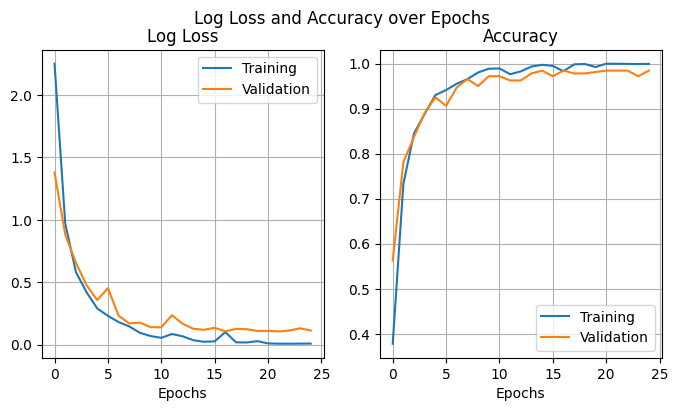

In [ ]:
# increasing the number of filters (e.g. 4, 8, 16, 32, ...)
args=[({'filters':2, 'kernel_size':(3,3)}, {'pool_size':(2,2)})]

# define a convolutional neural network
cnn = Convolutional_Neural_Network(X_train, Y_train, args)

# training process (with/without momentum)
#cnn.train(LR=0.0006, epochs=20, momentum=0.0, validation_split=0.1) # <- without momentum
#cnn.train(LR=0.0006, epochs=20, momentum=0.9, validation_split=0.1) # <- with momentum
#cnn.train(LR=0.0006, epochs=20, optimizer='Adam', validation_split=0.1) # <- Adam
#cnn.train(LR=0.001, epochs=20, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.001
#cnn.train(LR=0.05, epochs=20, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.05
#cnn.train(LR=0.08, epochs=20, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.08
#cnn.train(LR=0.005, epochs=20, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.005
#cnn.train(LR=0.001, epochs=15, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.001 and epochs = 15
cnn.train(LR=0.001, epochs=25, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.001 and epochs = 25
#cnn.train(LR=0.001, epochs=30, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.001 and epochs = 30
#cnn.train(LR=0.001, epochs=35, optimizer='Adam', validation_split=0.1) # <- Adam with LR=0.001 and epochs = 35



# plot error/accuracy history
cnn.plot_loss_accuracy()

# evaluate model
loss, acc = cnn.model.evaluate(X_test, Y_test, verbose=0)
print(f'Loss: {loss}\nAccuracy: {acc}')

|Parameters|Loss|Accuracy|
|---|---|---|
|LR=0.0006, epochs=20, momentum=0.0| 2.07|0.49|
|LR=0.0006, epochs=20, momentum=0.9| 0.2|0.95|
|LR=0.0006, epochs=20, optimizer='Adam'|0.13|0.977|
|LR=0.001, epochs=20, optimizer='Adam'| 0.13| 0.980|
|LR=0.05, epochs=20, optimizer='Adam'| 0.11|0.972|
|LR=0.08, epochs=20, optimizer='Adam'|0.15|0.977|
|LR=0.005, epochs=20, optimizer='Adam'|0.14| 0.977|
|LR=0.001, epochs=15, optimizer='Adam'| 0.1|0.977|
|LR=0.001, epochs=25, optimizer='Adam'|0.09|0.982|
|LR=0.001, epochs=30, optimizer='Adam'|0.08|0.981|
|LR=0.001, epochs=35, optimizer='Adam'| 0.07|0.982|


The best result was achived using "Adam" optimizer with LR = 0.001. The differances in accuracy between different amounts of epochs were very small. I have decided to go forward with epochs = 25 since it had 0.04 smaller loss than when epochs = 20; further changes make much smaller differances

## Final results

In [ ]:
acc_list = []

for _ in range(5):
  X_train, X_test, Y_train, Y_test = img_asl.get_encoded_images(height=80, width=80, test_size=0.2)

  # define model
  cnn = Convolutional_Neural_Network(X_train, Y_train)
  # train model
  cnn.train(LR=0.001, epochs=25, optimizer='Adam', validation_split=0.1)

  loss, accuracy = cnn.model.evaluate(X_test, Y_test, verbose=0)
  acc_list.append(round(accuracy, 4))


print(f"Average accuracy = {np.mean(acc_list)}")
print(f"Standard deviation = {round(np.std(acc_list), 4)}")
print(f"Best accuracy = {max(acc_list)}")

Average accuracy = 0.9759599999999999
Standard deviation = 0.0034
Best accuracy = 0.98


## Summarise

In [ ]:
def acc(c,t):
    if t == 0:
        return 0.0
    else:
        return np.round((c/t)*100, decimals=1)



In [ ]:
def accuracy_table(labels, y_train, y_test, y_pred):

    stats = {label: {'Total data': 0, 'Training data': 0, 'Test data': 0, 'Correct predictions': 0} for label in labels}

    label_to_index = {label: idx for idx, label in enumerate(labels)}
    index_to_label = {idx: label for idx, label in enumerate(labels)}

    y_train_indices = np.argmax(y_train, axis=1)
    y_test_indices = np.argmax(y_test, axis=1)
    y_pred_indices = np.argmax(y_pred, axis=1)

    # Calculate total data, training data, and test data counts
    for label in labels:
        stats[label]['Total data'] = len(img_asl.images[label])
        stats[label]['Training data'] = sum(y_train_indices == label_to_index[label])
        stats[label]['Test data'] = sum(y_test_indices == label_to_index[label])


    # Calculate correct predictions
    for true_index, pred_index in zip(y_test_indices, y_pred_indices):
        true_label = index_to_label[true_index]
        pred_label = index_to_label[pred_index]
        if true_label == pred_label:  # Check if the prediction is correct
            stats[true_label]['Correct predictions'] += 1

    # Create table
    columns = ["Label", "Total data", "Training data", "Test data", "Correct predictions", "Accuracy"]
    table = [(k, v["Total data"], v["Training data"],
                                   v["Test data"], v["Correct predictions"],
                                   acc(v["Correct predictions"], v["Test data"])) for k, v in stats.items()]
    return pd.DataFrame(table, columns=columns)

In [ ]:
predictions = cnn.model.predict(X_test, verbose = 0)


array([[1.6561995e-04, 7.4128601e-09, 4.3663513e-06, ..., 5.1711486e-18,
        1.7004702e-10, 3.0323338e-11],
       [1.9293102e-34, 0.0000000e+00, 0.0000000e+00, ..., 4.6215389e-20,
        8.0734623e-18, 1.2368669e-21],
       [2.1878220e-08, 9.5158139e-09, 3.4662760e-05, ..., 9.5952841e-15,
        5.5702975e-15, 1.5182959e-11],
       ...,
       [3.2864776e-12, 0.0000000e+00, 0.0000000e+00, ..., 5.3916924e-04,
        2.8454927e-10, 6.7393574e-10],
       [3.3145338e-09, 0.0000000e+00, 0.0000000e+00, ..., 5.8866351e-07,
        1.8323555e-04, 9.8864299e-01],
       [2.2143821e-08, 0.0000000e+00, 0.0000000e+00, ..., 2.3400308e-04,
        1.0192931e-05, 2.7558792e-01]], dtype=float32)

In [ ]:
accuracy_table(img_asl.categories, Y_train, Y_test, predictions)

{'0': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 22}, '1': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 22}, '2': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 22}, '3': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 22}, '4': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 20}, '5': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 21}, '6': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 16}, '7': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 19}, '8': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 22}, '9': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 21}, 'A': {'Total data': 111, 'Training data': 89, 'Test data': 22, 'Correct predictions': 21}

,Label,Total data,Training data,Test data,Correct predictions,Accuracy
0,0,111,89,22,22,100.0
1,1,111,89,22,22,100.0
2,2,111,89,22,22,100.0
3,3,111,89,22,22,100.0
4,4,111,89,22,20,90.9
5,5,111,89,22,21,95.5
6,6,111,89,22,16,72.7
7,7,111,89,22,19,86.4
8,8,111,89,22,22,100.0
9,9,111,89,22,21,95.5


from matplotlib import pyplot as plt
_df_0['Training data'].plot(kind='hist', bins=20, title='Training data')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Test data'].plot(kind='hist', bins=20, title='Test data')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Correct predictions'].plot(kind='hist', bins=20, title='Correct predictions')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Total data']
  ys = series['Accuracy']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_10.sort_values('Total data', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Total data')
_ = plt.ylabel('Accuracy')

from matplotlib import pyplot as plt
_df_11['Training data'].plot(kind='line', figsize=(8, 4), title='Training data')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_12['Test data'].plot(kind='line', figsize=(8, 4), title='Test data')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['Correct predictions'].plot(kind='line', figsize=(8, 4), title='Correct predictions')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['Accuracy'].plot(kind='line', figsize=(8, 4), title='Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

|index|Label|Total data|Training data|Test data|Correct predictions|Accuracy|
|---|---|---|---|---|---|---|
|0|0|111|89|22|22|100\.0|
|1|1|111|89|22|22|100\.0|
|2|2|111|89|22|22|100\.0|
|3|3|111|89|22|22|100\.0|
|4|4|111|89|22|20|90\.9|
|5|5|111|89|22|21|95\.5|
|6|6|111|89|22|16|72\.7|
|7|7|111|89|22|19|86\.4|
|8|8|111|89|22|22|100\.0|
|9|9|111|89|22|21|95\.5|
|10|A|111|89|22|21|95\.5|
|11|B|111|89|22|22|100\.0|
|12|C|111|89|22|22|100\.0|
|13|D|111|88|23|23|100\.0|
|14|E|111|88|23|23|100\.0|
|15|F|111|88|23|23|100\.0|
|16|G|111|88|23|23|100\.0|
|17|H|111|88|23|21|91\.3|
|18|I|111|89|22|22|100\.0|
|19|J|111|88|23|22|95\.7|
|20|K|111|89|22|22|100\.0|
|21|L|111|89|22|21|95\.5|
|22|M|111|88|23|23|100\.0|
|23|N|111|89|22|22|100\.0|
|24|O|111|89|22|21|95\.5|
|25|P|111|89|22|22|100\.0|
|26|Q|111|89|22|22|100\.0|
|27|R|111|89|22|22|100\.0|
|28|S|111|89|22|22|100\.0|
|29|T|111|89|22|22|100\.0|
|30|U|111|89|22|22|100\.0|
|31|V|111|88|23|23|100\.0|
|32|W|111|89|22|22|100\.0|
|33|X|111|89|22|22|100\.0|
|34|Y|111|89|22|22|100\.0|
|35|Z|111|89|22|21|95\.5|
